# Eksperymenty hiperparametrów

Notebook sprawdza, jak wybrane hiperparametry wpływają na accuracy modeli LSTM i Transformer dla rozpoznawania krótkich komend głosowych. Struktura jest podobna do `02_baseline_models.ipynb`: najpierw definicja konfiguracji, potem przygotowanie danych, uruchomienie treningów i analiza wyników. Notebook nie uruchamia eksperymentów automatycznie po otwarciu.

In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from scripts import (
    DataFixedParams,
    DataGridParams,
    Experiment,
    FeatureFixedParams,
    FitFixedParams,
    FitGridParams,
    LABEL_ORDER,
    ModelGridParams,
    experiment_grid_dataframe,
    prepare_experiment_datasets,
    train_experiment,
)

LABEL_ORDER

('yes',
 'no',
 'up',
 'down',
 'left',
 'right',
 'on',
 'off',
 'stop',
 'go',
 'unknown',
 'silence')

## Konfiguracja bazowa

Najważniejsze ustawienia są wypisane wprost w tej komórce. `BASE_HYPERPARAMETERS` to punkt odniesienia, a sekcja `STUDIES` niżej mówi, które wartości będą zmieniane w kolejnych eksperymentach.

In [16]:
EPOCHS = 3 #10
OUTPUT_DIR = "reports/03_hyperparameter_experiments"
# ARCHITECTURES = ["lstm", "transformer"]
ARCHITECTURES = ["transformer"]

DATA_GRID_CONFIG = {
    "train_fraction": 1, # 0.5,
    "validation_fraction": 1,
    "test_fraction": 1,
    "unknown_fraction": 1,
    "silence_samples": 1000,
    "sampling_strategy": "natural",
    "seed": 42,
}

FEATURE_CONFIG = {
    "n_mels": 64,
    "n_fft": 512,
    "hop_length": 160,
    "normalize": True,
}

FIT_FIXED_CONFIG = {
    "device": "cuda",
    "use_tqdm": True,
    "progress_backend": "terminal",
    "verbose": True,
    "early_stopping": True,

}

BASE_HYPERPARAMETERS = {
    "dropout": 0.2,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "batch_size": 128,
    "capacity": 128,
}

base_data_fixed = DataFixedParams(
    cache_dir=".cache/hyperparameter_audio",
    reuse_cached_dataset=False,
    output_dir=OUTPUT_DIR,
)
base_data_grid = DataGridParams(**DATA_GRID_CONFIG)
base_feature_fixed = FeatureFixedParams(**FEATURE_CONFIG)
base_fit_fixed = FitFixedParams(**FIT_FIXED_CONFIG)

pd.DataFrame(
    [
        {"group": "data", **DATA_GRID_CONFIG},
        {"group": "features", **FEATURE_CONFIG},
        {"group": "fit", **FIT_FIXED_CONFIG, "epochs": EPOCHS},
        {"group": "baseline", **BASE_HYPERPARAMETERS},
    ]
)

,group,train_fraction,validation_fraction,test_fraction,unknown_fraction,silence_samples,sampling_strategy,seed,n_mels,n_fft,...,use_tqdm,progress_backend,verbose,early_stopping,epochs,dropout,learning_rate,weight_decay,batch_size,capacity
0,data,1.0,1.0,1.0,1.0,1000.0,natural,42.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,features,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.0,512.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,fit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,True,terminal,True,False,3.0,NaN,NaN,NaN,NaN,NaN
3,baseline,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.2,0.001,0.0001,128.0,128.0


## Konfiguracje eksperymentów

Poniższa tabela jest głównym miejscem edycji. Każde badanie zmienia jeden parametr względem `BASE_HYPERPARAMETERS`; pozostałe ustawienia zostają stałe.

In [17]:
STUDIES = [
    {"study": "architecture", "parameter": "model_type", "values": ["lstm", "transformer"]},
    {"study": "dropout", "parameter": "dropout", "values": [0.0, 0.1, 0.2, 0.4, 0.5]},
    {"study": "learning_rate", "parameter": "learning_rate", "values": [1e-4, 5e-4, 1e-3, 5e-3]},
    {"study": "weight_decay", "parameter": "weight_decay", "values": [0.0, 1e-5, 1e-4, 1e-3]},
    {"study": "batch_size", "parameter": "batch_size", "values": [32, 64, 128, 256]},
    {"study": "capacity", "parameter": "model_capacity", "values": [32, 64, 128, 256]},
]

pd.DataFrame(STUDIES)

,study,parameter,values
0,architecture,model_type,"[lstm, transformer]"
1,dropout,dropout,"[0.0, 0.1, 0.2, 0.4, 0.5]"
2,learning_rate,learning_rate,"[0.0001, 0.0005, 0.001, 0.005]"
3,weight_decay,weight_decay,"[0.0, 1e-05, 0.0001, 0.001]"
4,batch_size,batch_size,"[32, 64, 128, 256]"
5,capacity,model_capacity,"[32, 64, 128, 256]"


In [18]:
def slug_value(value) -> str:
    return str(value).replace("-", "m").replace(".", "p")


def overrides_for(parameter: str, value) -> dict:
    if parameter == "model_type":
        return {}
    if parameter == "model_capacity":
        return {"capacity": value}
    return {parameter: value}


def make_experiment(name: str, architecture: str, overrides: dict | None = None) -> Experiment:
    hp = {**BASE_HYPERPARAMETERS, **(overrides or {})}

    return Experiment(
        name=name,
        data_fixed=base_data_fixed,
        data_grid=base_data_grid,
        feature_fixed=base_feature_fixed,
        model_grid=ModelGridParams(
            model_type=architecture,
            dropout=hp["dropout"],
            lstm_hidden_size=hp["capacity"],
            lstm_layers=2,
            lstm_bidirectional=True,
            transformer_d_model=hp["capacity"],
            transformer_heads=4,
            transformer_layers=2,
            transformer_ff_dim=hp["capacity"] * 2,
        ),
        fit_fixed=base_fit_fixed,
        fit_grid=FitGridParams(
            epochs=EPOCHS,
            batch_size=hp["batch_size"],
            learning_rate=hp["learning_rate"],
            weight_decay=hp["weight_decay"],
        ),
    )


experiments = {}
plan_rows = []

for spec in STUDIES:
    parameter = spec["parameter"]
    for value in spec["values"]:
        architectures = [value] if parameter == "model_type" else ARCHITECTURES
        for architecture in architectures:
            overrides = overrides_for(parameter, value)
            hp = {**BASE_HYPERPARAMETERS, **overrides}
            experiment_name = f"03_{spec['study']}_{architecture}_{parameter}_{slug_value(value)}"

            experiments[experiment_name] = make_experiment(experiment_name, architecture, overrides)
            plan_rows.append(
                {
                    "study": spec["study"],
                    "parameter": parameter,
                    "value": value,
                    "architecture": architecture,
                    **hp,
                    "experiment_name": experiment_name,
                    "runs": 1,
                }
            )

experiment_plan = pd.DataFrame(plan_rows)
plan_columns = [
    "study",
    "parameter",
    "value",
    "architecture",
    "dropout",
    "learning_rate",
    "weight_decay",
    "batch_size",
    "capacity",
    "experiment_name",
    "runs",
]

experiment_plan[plan_columns]

,study,parameter,value,architecture,dropout,learning_rate,weight_decay,batch_size,capacity,experiment_name,runs
0,architecture,model_type,lstm,lstm,0.2,0.0010,0.00010,128,128,03_architecture_lstm_model_type_lstm,1
1,architecture,model_type,transformer,transformer,0.2,0.0010,0.00010,128,128,03_architecture_transformer_model_type_transfo...,1
2,dropout,dropout,0.0,transformer,0.0,0.0010,0.00010,128,128,03_dropout_transformer_dropout_0p0,1
3,dropout,dropout,0.1,transformer,0.1,0.0010,0.00010,128,128,03_dropout_transformer_dropout_0p1,1
4,dropout,dropout,0.2,transformer,0.2,0.0010,0.00010,128,128,03_dropout_transformer_dropout_0p2,1
5,dropout,dropout,0.4,transformer,0.4,0.0010,0.00010,128,128,03_dropout_transformer_dropout_0p4,1
6,dropout,dropout,0.5,transformer,0.5,0.0010,0.00010,128,128,03_dropout_transformer_dropout_0p5,1
7,learning_rate,learning_rate,0.0001,transformer,0.2,0.0001,0.00010,128,128,03_learning_rate_transformer_learning_rate_0p0001,1
8,learning_rate,learning_rate,0.0005,transformer,0.2,0.0005,0.00010,128,128,03_learning_rate_transformer_learning_rate_0p0005,1
9,learning_rate,learning_rate,0.001,transformer,0.2,0.0010,0.00010,128,128,03_learning_rate_transformer_learning_rate_0p001,1


In [19]:
experiment_plan.groupby("study", as_index=False)["runs"].sum()

,study,runs
0,architecture,2
1,batch_size,4
2,capacity,4
3,dropout,5
4,learning_rate,4
5,weight_decay,4


## Wybór konfiguracji

Domyślnie zaznaczone są wszystkie badania. Jeśli chcesz uruchomić tylko część, usuń wybrane nazwy z `selected_studies` przed wykonaniem komórek treningowych.

In [20]:
selected_studies = [
    "architecture",
    "dropout",
    # "learning_rate",
    # "weight_decay",
    # "batch_size",
    # "capacity",
]

selected_plan = experiment_plan[experiment_plan["study"].isin(selected_studies)].reset_index(drop=True)
selected_plan[plan_columns]

,study,parameter,value,architecture,dropout,learning_rate,weight_decay,batch_size,capacity,experiment_name,runs
0,architecture,model_type,lstm,lstm,0.2,0.001,0.0001,128,128,03_architecture_lstm_model_type_lstm,1
1,architecture,model_type,transformer,transformer,0.2,0.001,0.0001,128,128,03_architecture_transformer_model_type_transfo...,1
2,dropout,dropout,0.0,transformer,0.0,0.001,0.0001,128,128,03_dropout_transformer_dropout_0p0,1
3,dropout,dropout,0.1,transformer,0.1,0.001,0.0001,128,128,03_dropout_transformer_dropout_0p1,1
4,dropout,dropout,0.2,transformer,0.2,0.001,0.0001,128,128,03_dropout_transformer_dropout_0p2,1
5,dropout,dropout,0.4,transformer,0.4,0.001,0.0001,128,128,03_dropout_transformer_dropout_0p4,1
6,dropout,dropout,0.5,transformer,0.5,0.001,0.0001,128,128,03_dropout_transformer_dropout_0p5,1


In [21]:
# Pełna konfiguracja pierwszego zaplanowanego eksperymentu.
example_experiment = experiments[selected_plan.loc[0, "experiment_name"]]
experiment_grid_dataframe(example_experiment)

,experiment,data.train_fraction,data.validation_fraction,data.test_fraction,data.unknown_fraction,data.silence_samples,data.sampling_strategy,data.seed,model.model_type,model.dropout,...,model.lstm_layers,model.lstm_bidirectional,model.transformer_d_model,model.transformer_heads,model.transformer_layers,model.transformer_ff_dim,fit.epochs,fit.batch_size,fit.learning_rate,fit.weight_decay
0,03_architecture_lstm_model_type_lstm,1,1,1,1,1000,natural,42,lstm,0.2,...,2,True,128,4,2,256,3,128,0.001,0.0001


## Przygotowanie danych

Dane są przygotowywane raz, bo wszystkie eksperymenty korzystają z identycznego podziału danych. Potem ten sam obiekt `prepared_data` jest przekazywany do kolejnych treningów.

In [22]:
data_cache_experiment = make_experiment(
    "03_shared_hyperparameter_data_cache",
    architecture="lstm",
)

prepared_data = prepare_experiment_datasets(data_cache_experiment)


Building dataset


Extracting archive: 100%|██████████| 1/1 [00:48<00:00, 48.49s/it]


  -> samples | train=51877 | validation=6903 | test=6941
     class        train  validation  test
     down         1842         264   253
     go           1861         260   251
     left         1839         247   267
     no           1853         270   252
     off          1839         256   262
     on           1864         257   246
     right        1852         256   259
     silence       789         105   106
     stop         1885         246   249
     unknown     32550        4221  4268
     up           1843         260   272
     yes          1860         261   256


## Uruchomienie eksperymentów

Ta komórka uruchamia wszystkie konfiguracje z `selected_plan`. Każdy trening ma ustawione `epochs=20`.

In [23]:
all_results = []

for index, row in selected_plan.iterrows():
    experiment_name = row["experiment_name"]
    experiment = experiments[experiment_name]
    print(f"[{index + 1}/{len(selected_plan)}] {experiment_name}")

    summary = train_experiment(experiment, prepared_data).copy()
    summary.insert(0, "study", row["study"])
    summary.insert(1, "parameter", row["parameter"])
    summary.insert(2, "value", row["value"])
    summary.insert(3, "architecture", row["architecture"])
    summary.insert(4, "experiment_name", experiment_name)
    all_results.append(summary)

all_results = pd.concat(all_results, ignore_index=True)
output_path = Path(OUTPUT_DIR) / "hyperparameter_experiment_summary.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
all_results.to_csv(output_path, index=False)
all_results.sort_values("test_accuracy", ascending=False)

[1/7] 03_architecture_lstm_model_type_lstm
Starting experiment: 03_architecture_lstm_model_type_lstm

Configuration run 1/1:
DATA (variable):
  - train_fraction: 1
  - validation_fraction: 1
  - test_fraction: 1
  - unknown_fraction: 1
  - silence_samples: 1000
  - sampling_strategy: natural
  - seed: 42
MODEL (variable):
  - model_type: lstm
  - dropout: 0.2
  - lstm_hidden_size: 128
  - lstm_layers: 2
  - lstm_bidirectional: True
  - transformer_d_model: 128
  - transformer_heads: 4
  - transformer_layers: 2
  - transformer_ff_dim: 256
FIT (variable):
  - epochs: 3
  - batch_size: 128
  - learning_rate: 0.001
  - weight_decay: 0.0001

Training model
Using device: cuda


Training: 100%|██████████| 3/3 [02:49<00:00, 56.38s/it, loss=0.2428, lr=0.001, val_acc=0.9155, val_loss=0.2831]


Training finished in 175.82 seconds



Experiment finished | total runs = 1
[2/7] 03_architecture_transformer_model_type_transformer
Starting experiment: 03_architecture_transformer_model_type_transformer

Configuration run 1/1:
DATA (variable):
  - train_fraction: 1
  - validation_fraction: 1
  - test_fraction: 1
  - unknown_fraction: 1
  - silence_samples: 1000
  - sampling_strategy: natural
  - seed: 42
MODEL (variable):
  - model_type: transformer
  - dropout: 0.2
  - lstm_hidden_size: 128
  - lstm_layers: 2
  - lstm_bidirectional: True
  - transformer_d_model: 128
  - transformer_heads: 4
  - transformer_layers: 2
  - transformer_ff_dim: 256
FIT (variable):
  - epochs: 3
  - batch_size: 128
  - learning_rate: 0.001
  - weight_decay: 0.0001

Training model
Using device: cuda


Training: 100%|██████████| 3/3 [02:45<00:00, 55.31s/it, loss=0.2427, lr=0.001, val_acc=0.9216, val_loss=0.2555]


Training finished in 172.30 seconds



Experiment finished | total runs = 1
[3/7] 03_dropout_transformer_dropout_0p0
Starting experiment: 03_dropout_transformer_dropout_0p0

Configuration run 1/1:
DATA (variable):
  - train_fraction: 1
  - validation_fraction: 1
  - test_fraction: 1
  - unknown_fraction: 1
  - silence_samples: 1000
  - sampling_strategy: natural
  - seed: 42
MODEL (variable):
  - model_type: transformer
  - dropout: 0.0
  - lstm_hidden_size: 128
  - lstm_layers: 2
  - lstm_bidirectional: True
  - transformer_d_model: 128
  - transformer_heads: 4
  - transformer_layers: 2
  - transformer_ff_dim: 256
FIT (variable):
  - epochs: 3
  - batch_size: 128
  - learning_rate: 0.001
  - weight_decay: 0.0001

Training model
Using device: cuda


...

Training: 100%|██████████| 3/3 [02:58<00:00, 59.42s/it, loss=0.2868, lr=0.001, val_acc=0.9189, val_loss=0.2965]


Training finished in 185.01 seconds



Experiment finished | total runs = 1
[7/7] 03_dropout_transformer_dropout_0p5
Starting experiment: 03_dropout_transformer_dropout_0p5

Configuration run 1/1:
DATA (variable):
  - train_fraction: 1
  - validation_fraction: 1
  - test_fraction: 1
  - unknown_fraction: 1
  - silence_samples: 1000
  - sampling_strategy: natural
  - seed: 42
MODEL (variable):
  - model_type: transformer
  - dropout: 0.5
  - lstm_hidden_size: 128
  - lstm_layers: 2
  - lstm_bidirectional: True
  - transformer_d_model: 128
  - transformer_heads: 4
  - transformer_layers: 2
  - transformer_ff_dim: 256
FIT (variable):
  - epochs: 3
  - batch_size: 128
  - learning_rate: 0.001
  - weight_decay: 0.0001

Training model
Using device: cuda


Training: 100%|██████████| 3/3 [03:09<00:00, 63.19s/it, loss=0.3236, lr=0.001, val_acc=0.9024, val_loss=0.3699]


Training finished in 196.21 seconds



Experiment finished | total runs = 1


,study,parameter,value,architecture,experiment_name,run,best_epoch,epochs_trained,stopped_early,train_loss,train_accuracy,validation_loss,validation_accuracy,test_loss,test_accuracy
2,dropout,dropout,0.0,transformer,03_dropout_transformer_dropout_0p0,trfm_train1_val1_test1_lr0_001_seed42,3,3,False,0.201293,0.936851,0.220228,0.928582,0.253076,0.923642
1,architecture,model_type,transformer,transformer,03_architecture_transformer_model_type_transfo...,trfm_train1_val1_test1_lr0_001_seed42,3,3,False,0.242740,0.924167,0.255478,0.921628,0.272599,0.921625
4,dropout,dropout,0.2,transformer,03_dropout_transformer_dropout_0p2,trfm_train1_val1_test1_lr0_001_seed42,3,3,False,0.242740,0.924167,0.255478,0.921628,0.272599,0.921625
3,dropout,dropout,0.1,transformer,03_dropout_transformer_dropout_0p1,trfm_train1_val1_test1_lr0_001_seed42,3,3,False,0.222799,0.930258,0.246815,0.921628,0.282842,0.915718
5,dropout,dropout,0.4,transformer,03_dropout_transformer_dropout_0p4,trfm_train1_val1_test1_lr0_001_seed42,3,3,False,0.286810,0.910789,0.296459,0.918876,0.310933,0.913269
0,architecture,model_type,lstm,lstm,03_architecture_lstm_model_type_lstm,lstm_train1_val1_test1_lr0_001_seed42,3,3,False,0.242769,0.925805,0.283066,0.915544,0.286221,0.912549
6,dropout,dropout,0.5,transformer,03_dropout_transformer_dropout_0p5,trfm_train1_val1_test1_lr0_001_seed42,3,3,False,0.323610,0.901440,0.369890,0.902361,0.390002,0.902464


## Wczytanie zapisanych wyników

Jeśli notebook został przerwany po treningu, ta komórka pozwala wrócić do analizy bez ponownego uruchamiania modeli.

In [24]:
summary_path = Path(OUTPUT_DIR) / "hyperparameter_experiment_summary.csv"

if summary_path.exists():
    all_results = pd.read_csv(summary_path)

all_results.sort_values("test_accuracy", ascending=False).head(10)

,study,parameter,value,architecture,experiment_name,run,best_epoch,epochs_trained,stopped_early,train_loss,train_accuracy,validation_loss,validation_accuracy,test_loss,test_accuracy
2,dropout,dropout,0.0,transformer,03_dropout_transformer_dropout_0p0,trfm_train1_val1_test1_lr0_001_seed42,3,3,False,0.201293,0.936851,0.220228,0.928582,0.253076,0.923642
1,architecture,model_type,transformer,transformer,03_architecture_transformer_model_type_transfo...,trfm_train1_val1_test1_lr0_001_seed42,3,3,False,0.242740,0.924167,0.255478,0.921628,0.272599,0.921625
4,dropout,dropout,0.2,transformer,03_dropout_transformer_dropout_0p2,trfm_train1_val1_test1_lr0_001_seed42,3,3,False,0.242740,0.924167,0.255478,0.921628,0.272599,0.921625
3,dropout,dropout,0.1,transformer,03_dropout_transformer_dropout_0p1,trfm_train1_val1_test1_lr0_001_seed42,3,3,False,0.222799,0.930258,0.246815,0.921628,0.282842,0.915718
5,dropout,dropout,0.4,transformer,03_dropout_transformer_dropout_0p4,trfm_train1_val1_test1_lr0_001_seed42,3,3,False,0.286810,0.910789,0.296459,0.918876,0.310933,0.913269
0,architecture,model_type,lstm,lstm,03_architecture_lstm_model_type_lstm,lstm_train1_val1_test1_lr0_001_seed42,3,3,False,0.242769,0.925805,0.283066,0.915544,0.286221,0.912549
6,dropout,dropout,0.5,transformer,03_dropout_transformer_dropout_0p5,trfm_train1_val1_test1_lr0_001_seed42,3,3,False,0.323610,0.901440,0.369890,0.902361,0.390002,0.902464


## Analiza wyników

Poniższe komórki porównują najlepsze konfiguracje oraz pokazują wpływ pojedynczych hiperparametrów osobno dla LSTM i Transformera.

In [25]:
best_by_study = (
    all_results.sort_values("test_accuracy", ascending=False)
    .groupby(["study", "architecture"], as_index=False)
    .first()
)

best_by_study[[
    "study",
    "architecture",
    "parameter",
    "value",
    "test_accuracy",
    "validation_accuracy",
    "best_epoch",
    "epochs_trained",
    "stopped_early",
]]

,study,architecture,parameter,value,test_accuracy,validation_accuracy,best_epoch,epochs_trained,stopped_early
0,architecture,lstm,model_type,lstm,0.912549,0.915544,3,3,False
1,architecture,transformer,model_type,transformer,0.921625,0.921628,3,3,False
2,dropout,transformer,dropout,0.0,0.923642,0.928582,3,3,False


In [26]:
accuracy_table = all_results.pivot_table(
    index=["study", "parameter", "value"],
    columns="architecture",
    values="test_accuracy",
    aggfunc="max",
).reset_index()

accuracy_table

architecture,study,parameter,value,lstm,transformer
0,architecture,model_type,lstm,0.912549,NaN
1,architecture,model_type,transformer,NaN,0.921625
2,dropout,dropout,0.0,NaN,0.923642
3,dropout,dropout,0.1,NaN,0.915718
4,dropout,dropout,0.2,NaN,0.921625
5,dropout,dropout,0.4,NaN,0.913269
6,dropout,dropout,0.5,NaN,0.902464


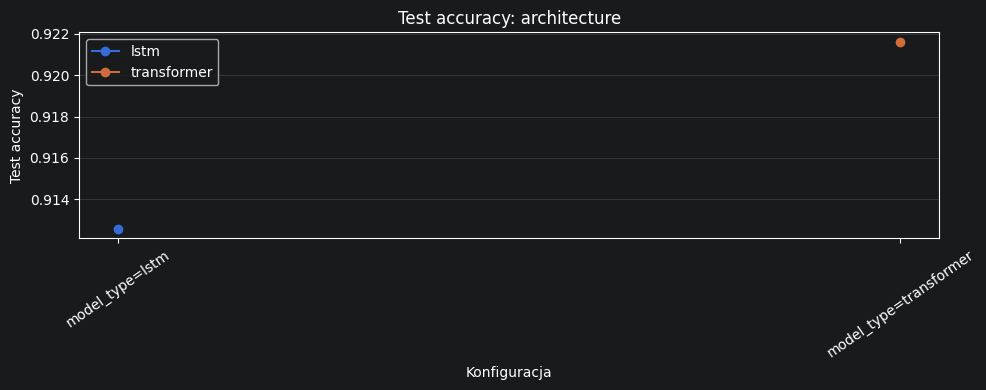

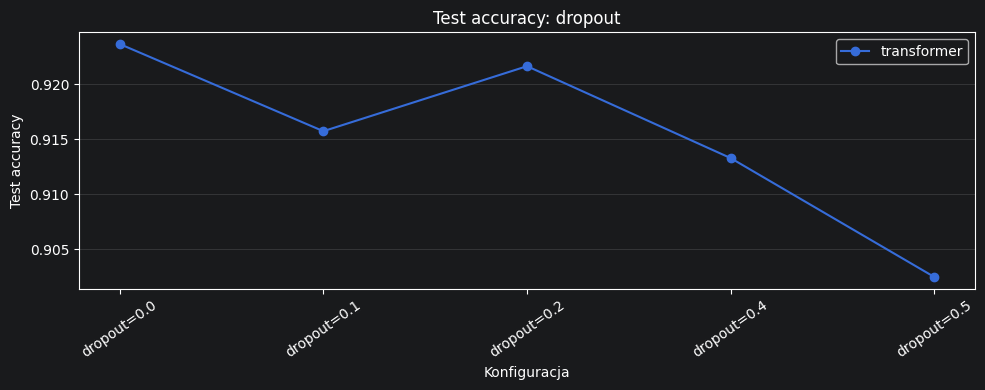

In [27]:
plot_data = all_results.copy()
plot_data["label"] = plot_data["parameter"] + "=" + plot_data["value"].astype(str)

for study, study_data in plot_data.groupby("study", sort=False):
    fig, axis = plt.subplots(figsize=(10, 4))
    for architecture, architecture_data in study_data.groupby("architecture", sort=False):
        axis.plot(
            architecture_data["label"],
            architecture_data["test_accuracy"],
            marker="o",
            label=architecture,
        )

    axis.set_title(f"Test accuracy: {study}")
    axis.set_xlabel("Konfiguracja")
    axis.set_ylabel("Test accuracy")
    axis.tick_params(axis="x", rotation=35)
    axis.legend()
    axis.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    plt.show()

## Kandydaci do finalnego porównania

Po uruchomieniu eksperymentów ta komórka wybiera najlepsze wyniki per architektura. To dobry punkt startowy do kolejnego, małego eksperymentu łączącego najlepsze wartości.

In [28]:
final_candidates = (
    all_results.sort_values("test_accuracy", ascending=False)
    .groupby("architecture", as_index=False)
    .head(5)
    [[
        "architecture",
        "study",
        "parameter",
        "value",
        "test_accuracy",
        "validation_accuracy",
        "best_epoch",
        "experiment_name",
    ]]
)

final_candidates

,architecture,study,parameter,value,test_accuracy,validation_accuracy,best_epoch,experiment_name
2,transformer,dropout,dropout,0.0,0.923642,0.928582,3,03_dropout_transformer_dropout_0p0
1,transformer,architecture,model_type,transformer,0.921625,0.921628,3,03_architecture_transformer_model_type_transfo...
4,transformer,dropout,dropout,0.2,0.921625,0.921628,3,03_dropout_transformer_dropout_0p2
3,transformer,dropout,dropout,0.1,0.915718,0.921628,3,03_dropout_transformer_dropout_0p1
5,transformer,dropout,dropout,0.4,0.913269,0.918876,3,03_dropout_transformer_dropout_0p4
0,lstm,architecture,model_type,lstm,0.912549,0.915544,3,03_architecture_lstm_model_type_lstm
